In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import janitor

In [61]:
df = pd.read_csv("data/train.csv")
df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [62]:
df.describe()

,id,num_sold
count,230130.000000,221259.000000
mean,115064.500000,752.527382
std,66432.953062,690.165445
min,0.000000,5.000000
25%,57532.250000,219.000000
50%,115064.500000,605.000000
75%,172596.750000,1114.000000
max,230129.000000,5939.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        230130 non-null  int64  
 1   date      230130 non-null  object 
 2   country   230130 non-null  object 
 3   store     230130 non-null  object 
 4   product   230130 non-null  object 
 5   num_sold  221259 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 10.5+ MB


In [64]:
df.isna().sum()

id             0
date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

In [65]:
df['num_sold'].skew()

np.float64(1.415373452498392)

#### EDA

Text(0, 0.5, 'Frequency')

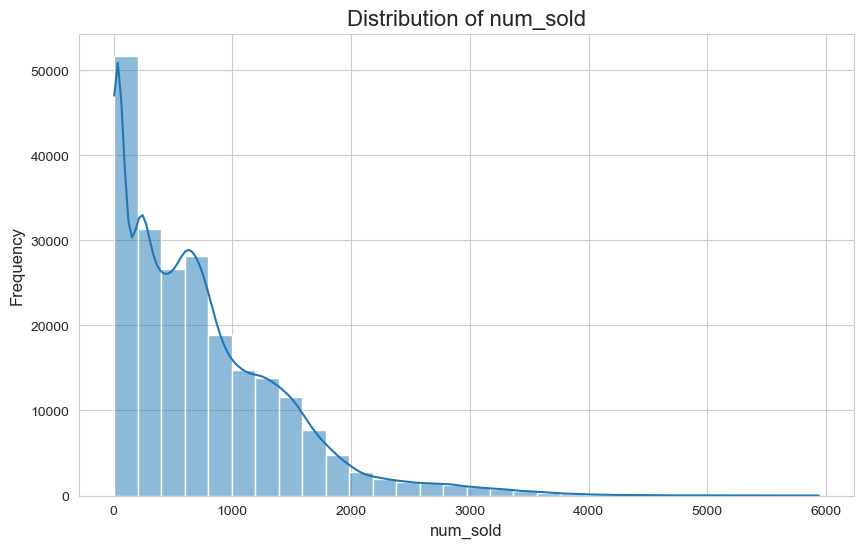

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_sold'], kde=True, bins=30)
plt.title('Distribution of num_sold', fontsize=16)
plt.xlabel('num_sold', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

Text(0.5, 1.0, 'Heatmap of Missing Values')

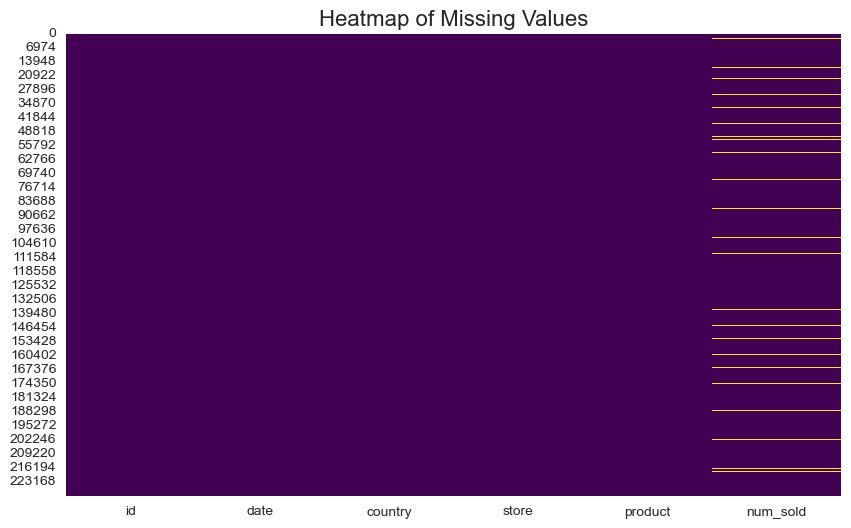

In [67]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values', fontsize=16)

<Axes: >

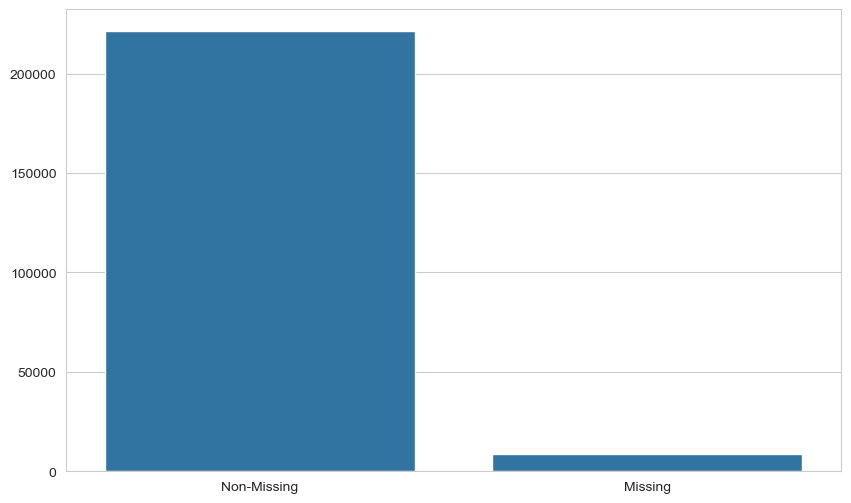

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=['Non-Missing','Missing'],
    y=[df['num_sold'].notnull().sum(), df['num_sold'].isnull().sum()],
    # palette='coolwarm'
            )

/var/folders/x4/rrw9x5l50yz_6clmyp_y58sm0000gn/T/ipykernel_98070/2063851755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y='num_sold', palette='Set2')


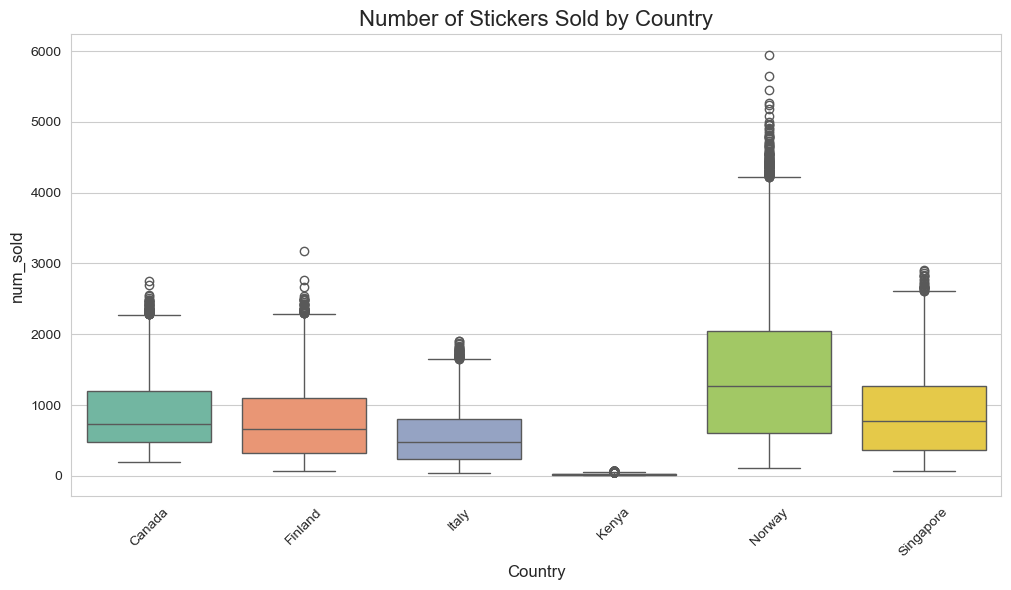

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='country', y='num_sold', palette='Set2')
plt.title('Number of Stickers Sold by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('num_sold', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='country', ylabel='count'>

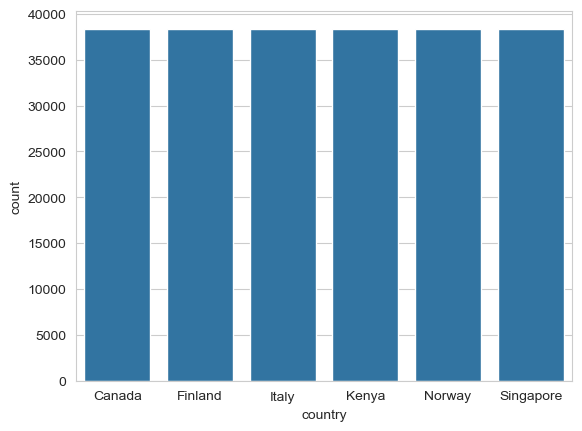

In [70]:
sns.barplot(df['country'].value_counts())

In [71]:
# sns.lineplot(data=df, x='date', y='num_sold', hue='country')

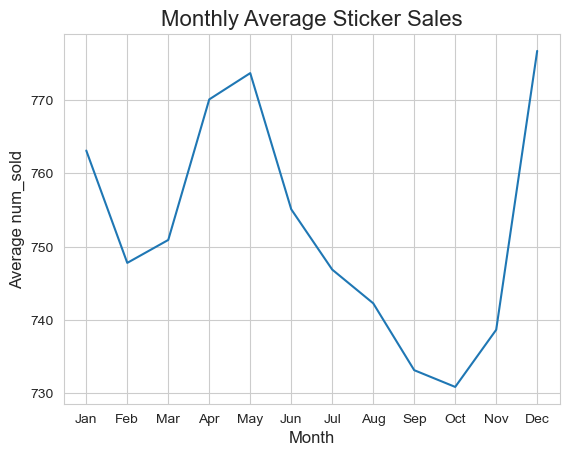

In [72]:
df['month'] = pd.to_datetime(df['date']).dt.month

sns.lineplot(df.groupby('month')['num_sold'].mean())
plt.title('Monthly Average Sticker Sales', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average num_sold', fontsize=12)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


/var/folders/x4/rrw9x5l50yz_6clmyp_y58sm0000gn/T/ipykernel_98070/1235229449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['day_of_week'], y=df['num_sold'], errorbar=None, palette='viridis')


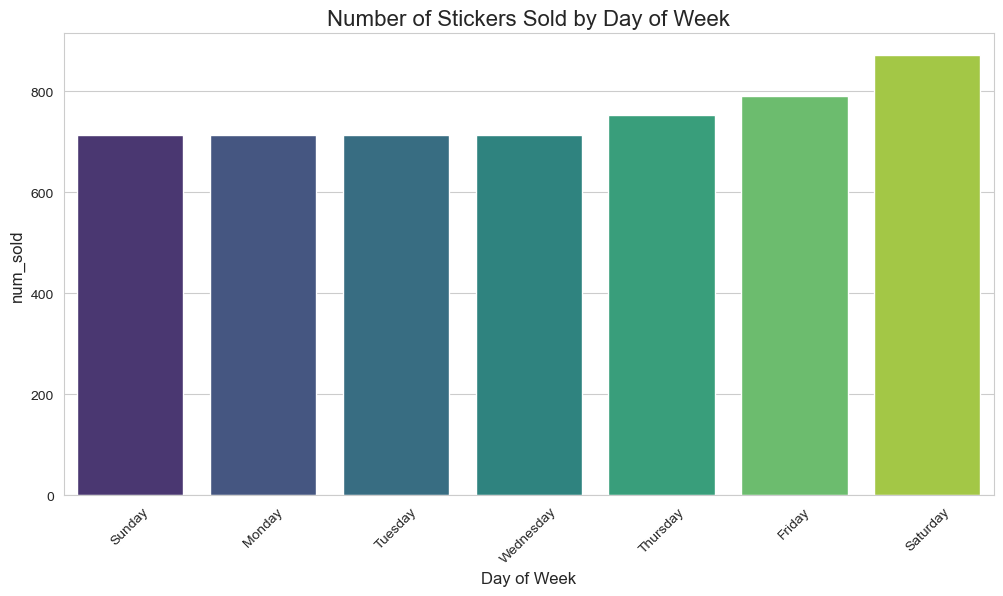

In [73]:
df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek

plt.figure(figsize=(12, 6))
sns.barplot(x=df['day_of_week'], y=df['num_sold'], errorbar=None, palette='viridis')
plt.title('Number of Stickers Sold by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('num_sold', fontsize=12)
plt.xticks([1,2,3,4,5,6,0], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xticks(rotation=45)
plt.show()

/var/folders/x4/rrw9x5l50yz_6clmyp_y58sm0000gn/T/ipykernel_98070/3326848793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df['num_sold'], palette='Set2')


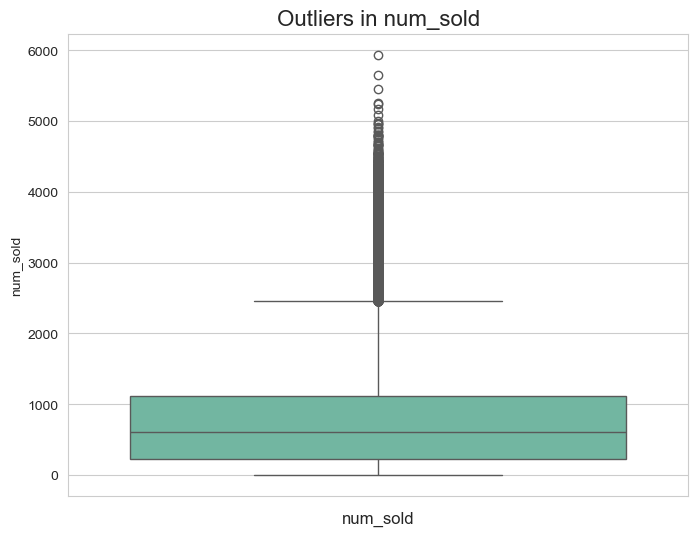

In [74]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df['num_sold'], palette='Set2')
plt.title('Outliers in num_sold', fontsize=16)
plt.xlabel('num_sold', fontsize=12)
plt.show()

In [75]:
df.head()

,id,date,country,store,product,num_sold,month,day_of_week
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN,1,4
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0,1,4
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,1,4
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0,1,4
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,1,4


In [76]:
df['num_sold'].fillna(df['num_sold'].median(), inplace=True)
df.isna().sum()

/var/folders/x4/rrw9x5l50yz_6clmyp_y58sm0000gn/T/ipykernel_98070/3556351880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['num_sold'].fillna(df['num_sold'].median(), inplace=True)


id             0
date           0
country        0
store          0
product        0
num_sold       0
month          0
day_of_week    0
dtype: int64

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           230130 non-null  int64  
 1   date         230130 non-null  object 
 2   country      230130 non-null  object 
 3   store        230130 non-null  object 
 4   product      230130 non-null  object 
 5   num_sold     230130 non-null  float64
 6   month        230130 non-null  int32  
 7   day_of_week  230130 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(4)
memory usage: 12.3+ MB


#### Modelling

In [78]:
test_df = pd.read_csv('data/test.csv')
test_df.isna().sum()

id         0
date       0
country    0
store      0
product    0
dtype: int64

In [79]:
# Either of these options work, one just fills with the overall median, the other fills with median per country per month
# df['num_sold'].fillna(df['num_sold'].median(), inplace=True)

# df['num_sold'] = df.groupby(['country','month'])['num_sold'].transform(lambda x: x.fillna(x.median()))


#### Feature Engineering

In [80]:
# Train df
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek
df['month'] = pd.to_datetime(df['date']).dt.month
df['year'] = pd.to_datetime(df['date']).dt.year

# Test df
test_df['date'] = pd.to_datetime(test_df['date'])
test_df['day_of_week'] = pd.to_datetime(test_df['date']).dt.dayofweek
test_df['month'] = pd.to_datetime(test_df['date']).dt.month
test_df['year'] = pd.to_datetime(test_df['date']).dt.year


In [81]:
df = pd.get_dummies(df, columns=['country','product','store'], drop_first=True).clean_names()
test_df = pd.get_dummies(test_df, columns=['country','product','store'], drop_first=True).clean_names()

In [82]:
test_df.head()

,id,date,day_of_week,month,year,country_finland,country_italy,country_kenya,country_norway,country_singapore,product_kaggle,product_kaggle_tiers,product_kerneler,product_kerneler_dark_mode,store_premium_sticker_mart,store_stickers_for_less
0,230130,2017-01-01,6,1,2017,False,False,False,False,False,False,False,False,False,False,False
1,230131,2017-01-01,6,1,2017,False,False,False,False,False,True,False,False,False,False,False
2,230132,2017-01-01,6,1,2017,False,False,False,False,False,False,True,False,False,False,False
3,230133,2017-01-01,6,1,2017,False,False,False,False,False,False,False,True,False,False,False
4,230134,2017-01-01,6,1,2017,False,False,False,False,False,False,False,False,True,False,False


In [83]:
X = df.drop(['num_sold','id','date'], axis=1)
y = df['num_sold']

X_test = test_df.drop(['id','date'], axis=1)

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
mape = mean_absolute_percentage_error(y_val, y_val_pred)
print(f'MAPE on validation set: {mape}')

MAPE on validation set: 0.23481685457866067


In [94]:
X_test = X_test[X_train.columns]
test_df['num_sold'] = rf.predict(X_test)
test_df

,id,date,day_of_week,month,year,country_finland,country_italy,country_kenya,country_norway,country_singapore,product_kaggle,product_kaggle_tiers,product_kerneler,product_kerneler_dark_mode,store_premium_sticker_mart,store_stickers_for_less,num_sold
0,230130,2017-01-01,6,1,2017,False,False,False,False,False,False,False,False,False,False,False,605.000000
1,230131,2017-01-01,6,1,2017,False,False,False,False,False,True,False,False,False,False,False,748.285825
2,230132,2017-01-01,6,1,2017,False,False,False,False,False,False,True,False,False,False,False,668.015714
3,230133,2017-01-01,6,1,2017,False,False,False,False,False,False,False,True,False,False,False,336.285583
4,230134,2017-01-01,6,1,2017,False,False,False,False,False,False,False,False,True,False,False,424.030755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98545,328675,2019-12-31,1,12,2019,False,False,False,False,True,False,False,False,False,True,False,304.811401
98546,328676,2019-12-31,1,12,2019,False,False,False,False,True,True,False,False,False,True,False,1985.583440
98547,328677,2019-12-31,1,12,2019,False,False,False,False,True,False,True,False,False,True,False,1623.356238
98548,328678,2019-12-31,1,12,2019,False,False,False,False,True,False,False,True,False,True,False,979.074881


In [95]:
submission = test_df[['id','num_sold']]
submission.head()

,id,num_sold
0,230130,605.000000
1,230131,748.285825
2,230132,668.015714
3,230133,336.285583
4,230134,424.030755


In [96]:
submission.to_csv('data/submission.csv', index=False)

In [97]:
pd.read_csv('data/train.csv').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        230130 non-null  int64  
 1   date      230130 non-null  object 
 2   country   230130 non-null  object 
 3   store     230130 non-null  object 
 4   product   230130 non-null  object 
 5   num_sold  221259 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 10.5+ MB
